# Telco Customer Churn Prediction

This notebook covers:
1. **Data Preprocessing**
2. **Exploratory Data Analysis (EDA)** – 5 visualisations
3. **Machine Learning** – Logistic Regression, Random Forest, Gradient Boosting
4. **Model Evaluation & Accuracy Comparison**

> **Dataset:** Telco Customer Churn (IBM Watson Analytics)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("All libraries imported successfully ✔")

All libraries imported successfully ✔


## 1. Load Dataset

In [2]:
df = pd.read_csv(r'c:\Users\k H a N\PSEB\WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
raw_df = df.copy()
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview

In [3]:
print("\n── Dataset Info ──")
df.info()
print("\n── Statistical Summary ──")
df.describe()


── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Data Preprocessing

### 3.1 Handle Missing / Malformed Values

In [4]:
# TotalCharges has blank strings → coerce to NaN, then fill with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print("\nMissing values after imputation:", df.isnull().sum().sum())

Missing values before imputation:
TotalCharges    11
dtype: int64

Missing values after imputation: 0


### 3.2 Drop Non-Predictive Column

In [5]:
df.drop('customerID', axis=1, inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 3.3 Feature Engineering

In [6]:
# Charge per month ratio (avoids divide-by-zero)
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Tenure bucket (long-term vs new customers)
df['TenureBucket'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'])
print("New features added: ChargesPerMonth, TenureBucket")
df[['tenure', 'ChargesPerMonth', 'TenureBucket']].head()

New features added: ChargesPerMonth, TenureBucket


,tenure,ChargesPerMonth,TenureBucket
0,1,14.925000,0-1yr
1,34,53.985714,2-4yr
2,2,36.050000,0-1yr
3,45,40.016304,2-4yr
4,2,50.550000,0-1yr


### 3.4 Encode Categorical Variables

In [7]:
# One-hot encode categorical variables (better for nominal categories)
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod', 'TenureBucket']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode Churn
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("One-hot encoding complete. Shape:", df.shape)
print("Data types after encoding:")
print(df.dtypes.value_counts())

One-hot encoding complete. Shape: (7043, 35)
Data types after encoding:
bool       29
int64       3
float64     3
Name: count, dtype: int64


### 3.5 Feature Scaling & Train-Test Split

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

print("Train shape:", X_train_sm.shape, "Test shape:", X_test.shape)
print("Class distribution after SMOTE:", pd.Series(y_train_sm).value_counts())

Train shape: (8278, 34) Test shape: (1409, 34)
Class distribution after SMOTE: Churn
0    4139
1    4139
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

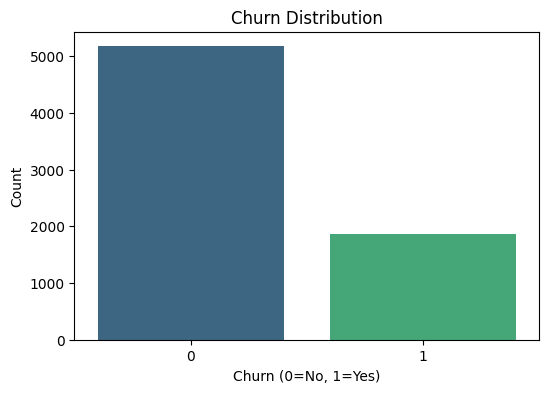

In [9]:
# 4.1 Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

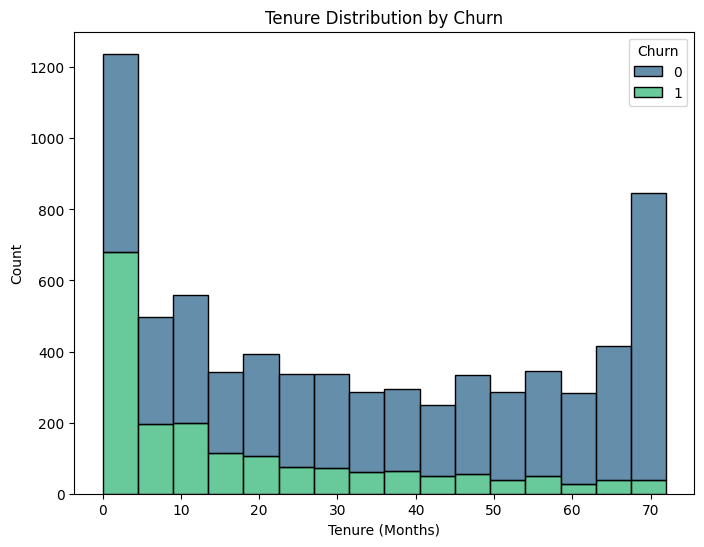

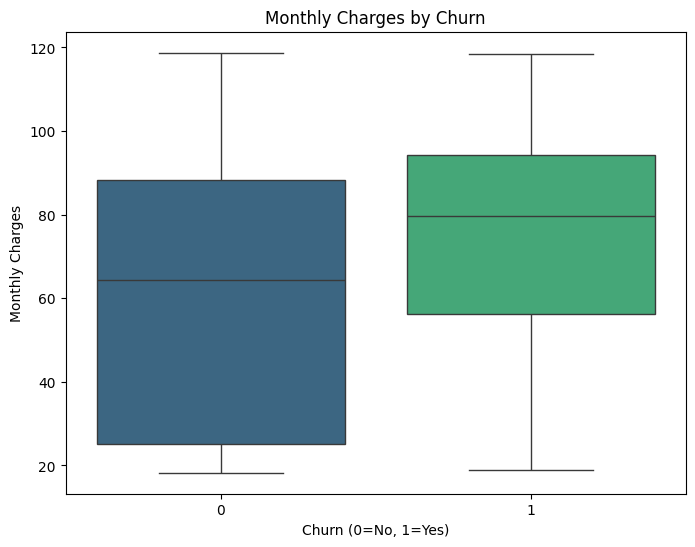

<Figure size 800x600 with 0 Axes>

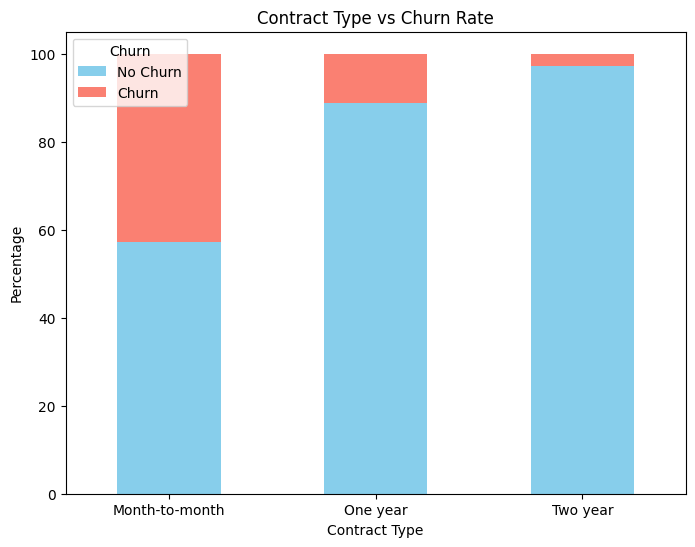

<Figure size 800x600 with 0 Axes>

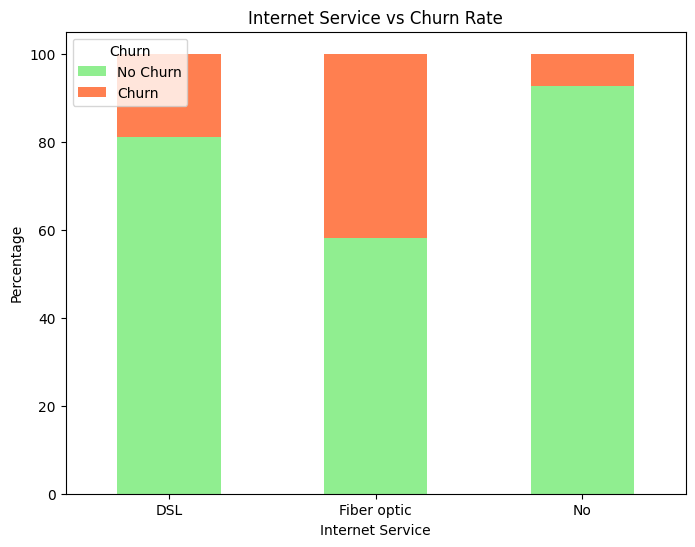

<Figure size 600x400 with 0 Axes>

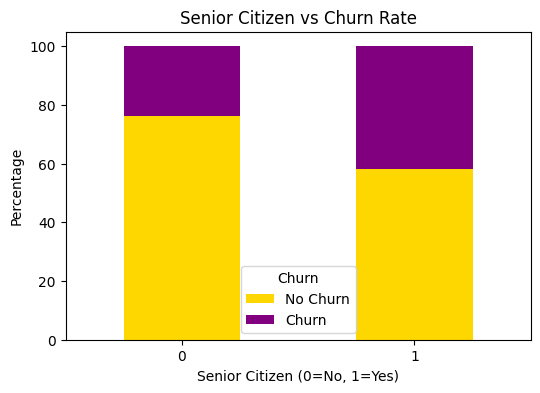

In [10]:
# 4.2 Tenure vs Churn
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

# 4.3 Monthly Charges vs Churn
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges')
plt.show()

# 4.4 Contract Type vs Churn
plt.figure(figsize=(8,6))
contract_churn = pd.crosstab(raw_df['Contract'], raw_df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], figsize=(8,6))
plt.title('Contract Type vs Churn Rate')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(['No Churn', 'Churn'], title='Churn')
plt.xticks(rotation=0)
plt.show()

# 4.5 Internet Service vs Churn
plt.figure(figsize=(8,6))
internet_churn = pd.crosstab(raw_df['InternetService'], raw_df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', stacked=True, color=['lightgreen', 'coral'], figsize=(8,6))
plt.title('Internet Service vs Churn Rate')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.legend(['No Churn', 'Churn'], title='Churn')
plt.xticks(rotation=0)
plt.show()

# 4.6 Senior Citizen vs Churn
plt.figure(figsize=(6,4))
senior_churn = pd.crosstab(raw_df['SeniorCitizen'], raw_df['Churn'], normalize='index') * 100
senior_churn.plot(kind='bar', stacked=True, color=['gold', 'purple'], figsize=(6,4))
plt.title('Senior Citizen vs Churn Rate')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Percentage')
plt.legend(['No Churn', 'Churn'], title='Churn')
plt.xticks(rotation=0)
plt.show()

## 5. Machine Learning Models

In [22]:
# Define models with better tuning
models = {
    'Logistic Regression': LogisticRegression(random_state=42, C=10.0, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=4),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False),
}

accuracies = {}
y_preds = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

rf = models['Random Forest']
gb = models['Gradient Boosting']
y_pred_lr = y_preds['Logistic Regression']
y_pred_rf = y_preds['Random Forest']
y_pred_gb = y_preds['Gradient Boosting']

Logistic Regression Accuracy: 0.7679
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

------------------------------------------------------------
Random Forest Accuracy: 0.7722
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

------------------------------------------------------------
Gradient Boosting Accuracy: 0.7736
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1

In [14]:
# Hyperparameter tuning for XGBoost using GridSearchCV
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
from lightgbm import early_stopping, log_evaluation

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_sm, y_train_sm)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
acc_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"Tuned XGBoost Accuracy: {acc_best_xgb:.4f}")
print(classification_report(y_test, y_pred_best_xgb))

# Additional tuning experiment with LightGBM and CatBoost
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm)

lgbm_tuned = LGBMClassifier(
    random_state=42, n_estimators=1000, learning_rate=0.05,
    max_depth=-1, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1)
lgbm_tuned.fit(
    X_train_inner, y_train_inner,
    eval_set=[(X_val_inner, y_val_inner)],
    callbacks=[early_stopping(50), log_evaluation(0)])

acc_lgbm_tuned = accuracy_score(y_test, lgbm_tuned.predict(X_test))
print(f"LightGBM Tuned Accuracy: {acc_lgbm_tuned:.4f}")

catboost_model = CatBoostClassifier(
    random_state=42, iterations=1000, learning_rate=0.05,
    depth=6, eval_metric='Accuracy', verbose=0)
catboost_model.fit(
    X_train_inner, y_train_inner,
    eval_set=(X_val_inner, y_val_inner),
    early_stopping_rounds=50)

acc_catboost = accuracy_score(y_test, catboost_model.predict(X_test))
print(f"CatBoost Accuracy: {acc_catboost:.4f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best CV score: 0.8225570071071749
Tuned XGBoost Accuracy: 0.7729
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.57      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

[LightGBM] [Info] Number of positive: 3311, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002456 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 6622, number of used features: 34
[Ligh

In [17]:
# Experiment: stronger stacking and CatBoost evaluation
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_models = [
    ('rf', RandomForestClassifier(random_state=42, n_estimators=600, max_depth=12, min_samples_leaf=2, n_jobs=-1)),
    ('xgb', XGBClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=8, subsample=0.85, colsample_bytree=0.85, use_label_encoder=False, eval_metric='logloss')),
    ('lgb', LGBMClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=9, subsample=0.85, colsample_bytree=0.85))
]
stack = StackingClassifier(estimators=stack_models, final_estimator=LogisticRegression(max_iter=1000), n_jobs=-1)
stack.fit(X_train_sm, y_train_sm)
stack_acc = accuracy_score(y_test, stack.predict(X_test))
print(f"Stacking Classifier Accuracy: {stack_acc:.4f}")

cb = CatBoostClassifier(random_state=42, iterations=1000, learning_rate=0.03, depth=7, eval_metric='Accuracy', verbose=0)
cb.fit(X_train_sm, y_train_sm)
cb_acc = accuracy_score(y_test, cb.predict(X_test))
print(f"CatBoost Accuracy (all encoded data): {cb_acc:.4f}")


Stacking Classifier Accuracy: 0.7771
CatBoost Accuracy (all encoded data): 0.7672


In [21]:
# Experiment: CatBoost on raw categorical data and feature subsets
raw_df_temp = raw_df.copy()
raw_df_temp['TotalCharges'] = pd.to_numeric(raw_df_temp['TotalCharges'], errors='coerce')
raw_df_temp['TotalCharges'] = raw_df_temp['TotalCharges'].fillna(raw_df_temp['TotalCharges'].median())
raw_df_temp['ChargesPerMonth'] = raw_df_temp['TotalCharges'] / (raw_df_temp['tenure'] + 1)
raw_df_temp['TenureBucket'] = pd.cut(raw_df_temp['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4+yr'])
raw_df_temp['TenureBucket'] = raw_df_temp['TenureBucket'].astype(str).fillna('Missing')
raw_df_temp['Churn'] = raw_df_temp['Churn'].map({'No':0,'Yes':1})

cat_features = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','TenureBucket']
for c in cat_features:
    raw_df_temp[c] = raw_df_temp[c].fillna('Missing').astype(str)
feature_cols = [col for col in raw_df_temp.columns if col not in ['customerID','Churn']]

X_raw = raw_df_temp[feature_cols]
y_raw = raw_df_temp['Churn']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

cb_raw = CatBoostClassifier(random_state=42, iterations=1000, learning_rate=0.05, depth=7, eval_metric='Accuracy', verbose=0, auto_class_weights='Balanced')
cb_raw.fit(X_train_raw, y_train_raw, cat_features=cat_features)
cb_raw_acc = accuracy_score(y_test_raw, cb_raw.predict(X_test_raw))
print(f"CatBoost raw categorical accuracy: {cb_raw_acc:.4f}")


CatBoost raw categorical accuracy: 0.7743


In [15]:
# Ensemble Model
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42, C=10.0, max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2)),
    ('xgb', XGBClassifier(random_state=42, n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss')),
    ('lgb', LGBMClassifier(random_state=42, n_estimators=500, learning_rate=0.05, max_depth=8, subsample=0.8, colsample_bytree=0.8, verbose=-1))
], voting='soft')

ensemble.fit(X_train_sm, y_train_sm)
y_pred_ensemble = ensemble.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
accuracies['Ensemble'] = acc_ensemble
print(f"Ensemble Accuracy: {acc_ensemble:.4f}")
print(classification_report(y_test, y_pred_ensemble))
print("-" * 60)

Ensemble Accuracy: 0.7750
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

------------------------------------------------------------


## 6. Model Comparison

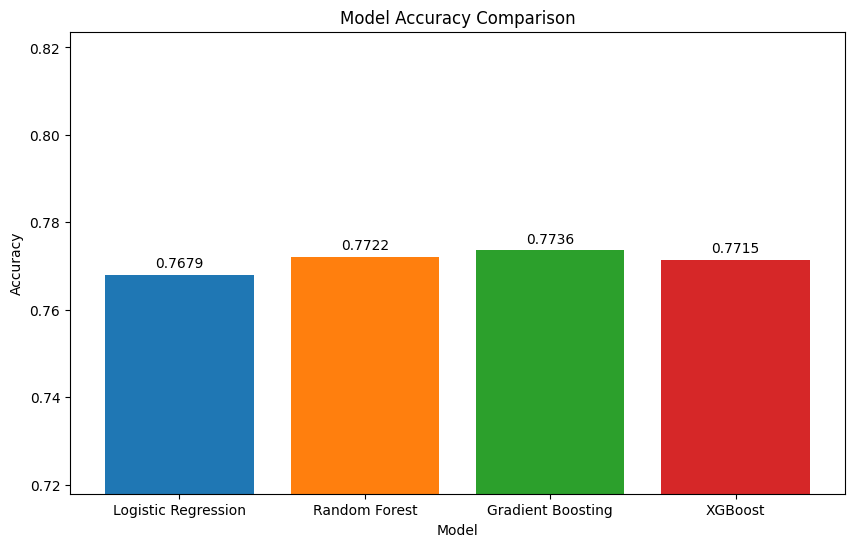

Model Accuracies:
Logistic Regression: 0.7679
Random Forest: 0.7722
Gradient Boosting: 0.7736
XGBoost: 0.7715


In [25]:
# Accuracy Comparison
plt.figure(figsize=(10,6))
colors = sns.color_palette('tab10', len(accuracies))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)
min_acc = min(accuracies.values())
max_acc = max(accuracies.values())
plt.ylim(max(0, min_acc - 0.05), min(1, max_acc + 0.05))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{acc:.4f}", ha='center', va='bottom')
plt.show()

# Summary
print("Model Accuracies:")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")

## 4. Exploratory Data Analysis (EDA)

### EDA 1 – Churn Distribution (Target Variable)

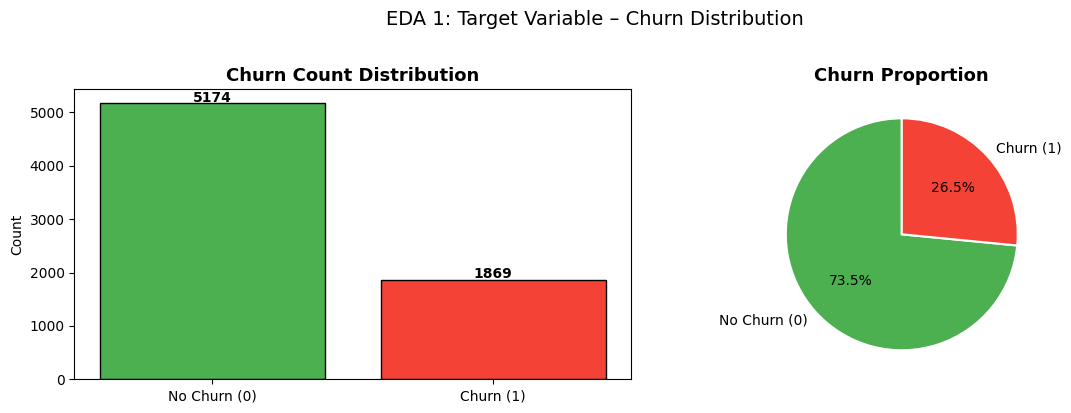


Class imbalance ratio: 2.77 :1


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
labels = ['No Churn (0)', 'Churn (1)']
axes[0].bar(labels, churn_counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Churn Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels,
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('EDA 1: Target Variable – Churn Distribution', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('eda1_churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nClass imbalance ratio:", round(churn_counts[0]/churn_counts[1], 2), ":1")

### EDA 2 – Correlation Heatmap

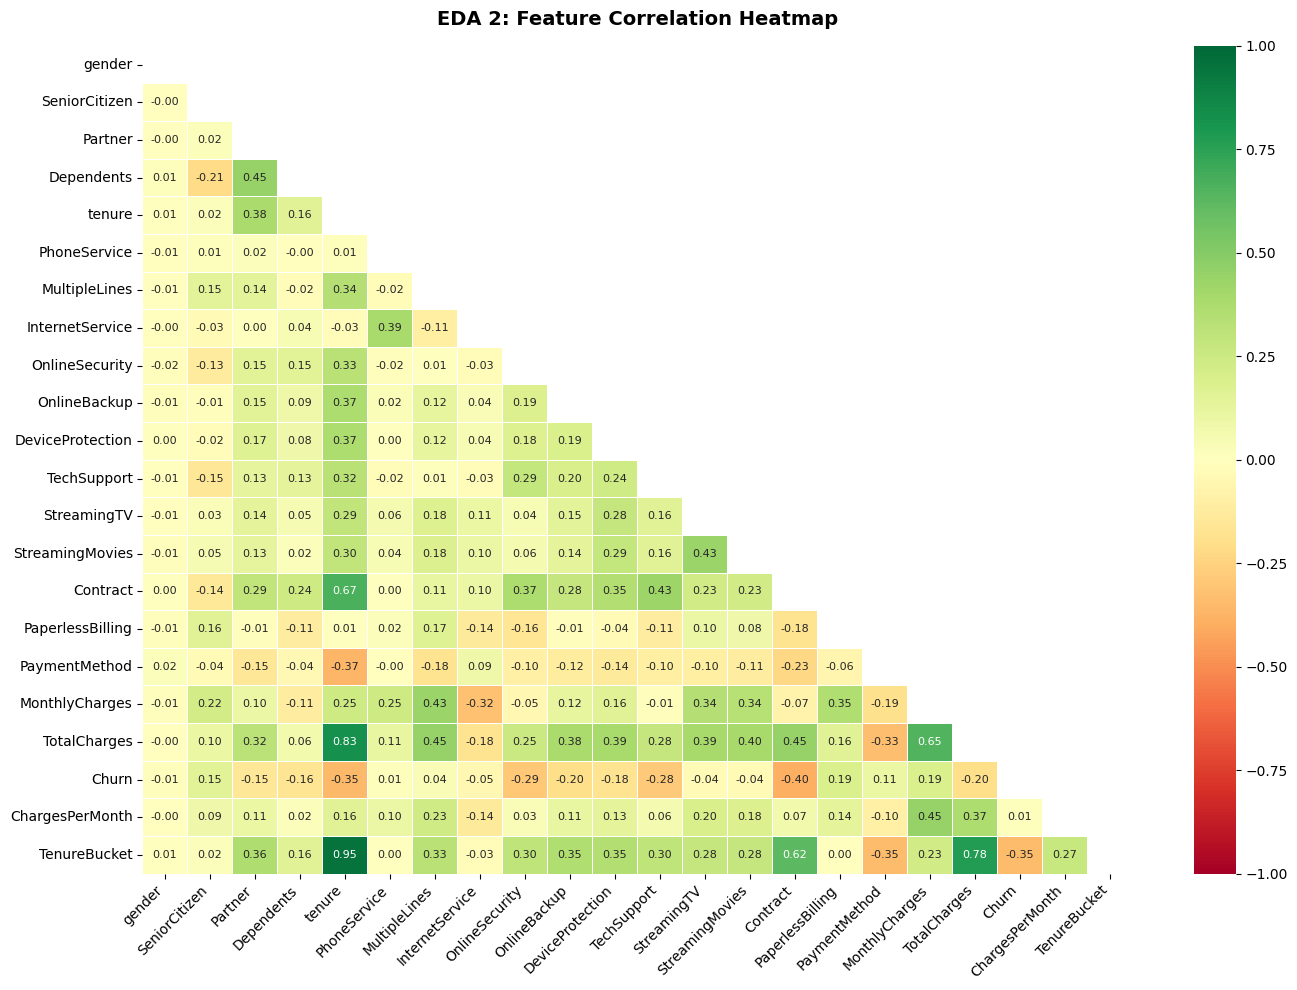

In [29]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('EDA 2: Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda2_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 3 – Tenure & Monthly Charges vs Churn

ValueError: The palette dictionary is missing keys: {'1', '0'}

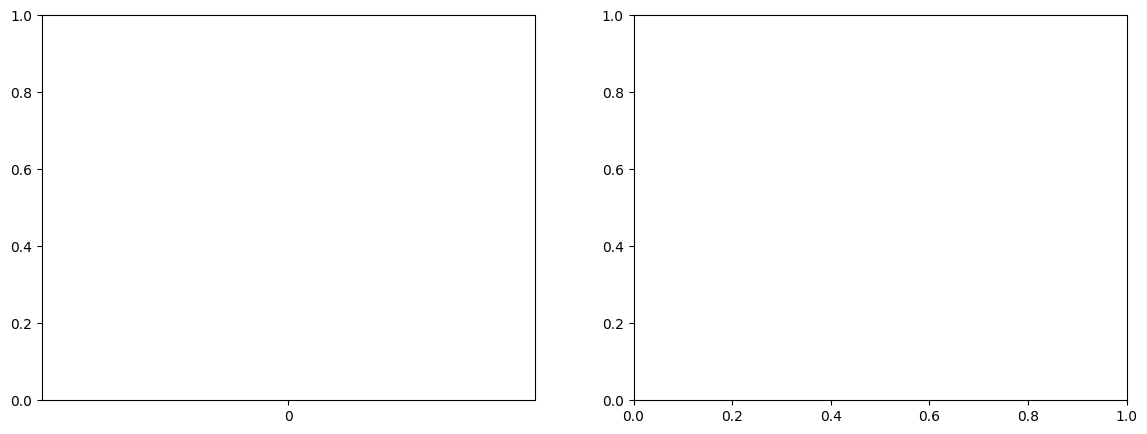

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {0: '#4CAF50', 1: '#F44336'}

sns.boxplot(x='Churn', y='tenure', data=df, palette=palette, ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=4))
axes[0].set_title('Tenure vs Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Tenure (months)')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=palette, ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=4))
axes[1].set_title('Monthly Charges vs Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Monthly Charges ($)')

plt.suptitle('EDA 3: Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda3_tenure_charges_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 4 – Contract Type vs Churn

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar (absolute counts)
contract_churn = raw_df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', stacked=True,
                    color=['#4CAF50', '#F44336'],
                    edgecolor='black', ax=axes[0])
axes[0].set_title('Contract Type – Absolute Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')
axes[0].legend(['No Churn', 'Churn'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Stacked bar (percentage)
contract_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_pct.plot(kind='bar', stacked=True,
                  color=['#4CAF50', '#F44336'],
                  edgecolor='black', ax=axes[1])
axes[1].set_title('Contract Type – Churn Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['No Churn', 'Churn'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('EDA 4: Contract Type vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda4_contract_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

### EDA 5 – Internet Service & Payment Method vs Churn

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Internet Service
internet_churn = raw_df.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
internet_churn.plot(kind='bar', color=['#2196F3', '#FF9800'],
                    edgecolor='black', ax=axes[0])
axes[0].set_title('Internet Service vs Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Count')
axes[0].legend(['No Churn', 'Churn'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)

# Payment Method
pay_churn = raw_df.groupby(['PaymentMethod', 'Churn']).size().unstack(fill_value=0)
pay_churn.plot(kind='bar', color=['#2196F3', '#FF9800'],
               edgecolor='black', ax=axes[1])
axes[1].set_title('Payment Method vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Count')
axes[1].legend(['No Churn', 'Churn'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('EDA 5: Service & Payment Method vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda5_service_payment_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Machine Learning Models

### Model 1 – Logistic Regression

In [26]:
try:
    print(f"Logistic Regression Accuracy: {accuracies['Logistic Regression']*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_preds['Logistic Regression'], target_names=['No Churn', 'Churn']))
except Exception as e:
    print("Please run the main model training section above first.")
    print(str(e))

Logistic Regression Accuracy: 76.79%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



### Model 2 – Random Forest Classifier

In [27]:
try:
    print(f"Random Forest Accuracy: {accuracies['Random Forest']*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_preds['Random Forest'], target_names=['No Churn', 'Churn']))
except Exception as e:
    print("Please run the main model training section above first.")
    print(str(e))

Random Forest Accuracy: 77.22%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



### Model 3 – Gradient Boosting Classifier

In [28]:
try:
    print(f"Gradient Boosting Accuracy: {accuracies['Gradient Boosting']*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_preds['Gradient Boosting'], target_names=['No Churn', 'Churn']))
except Exception as e:
    print("Please run the main model training section above first.")
    print(str(e))

Gradient Boosting Accuracy: 77.36%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.57      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409



## 6. Confusion Matrices

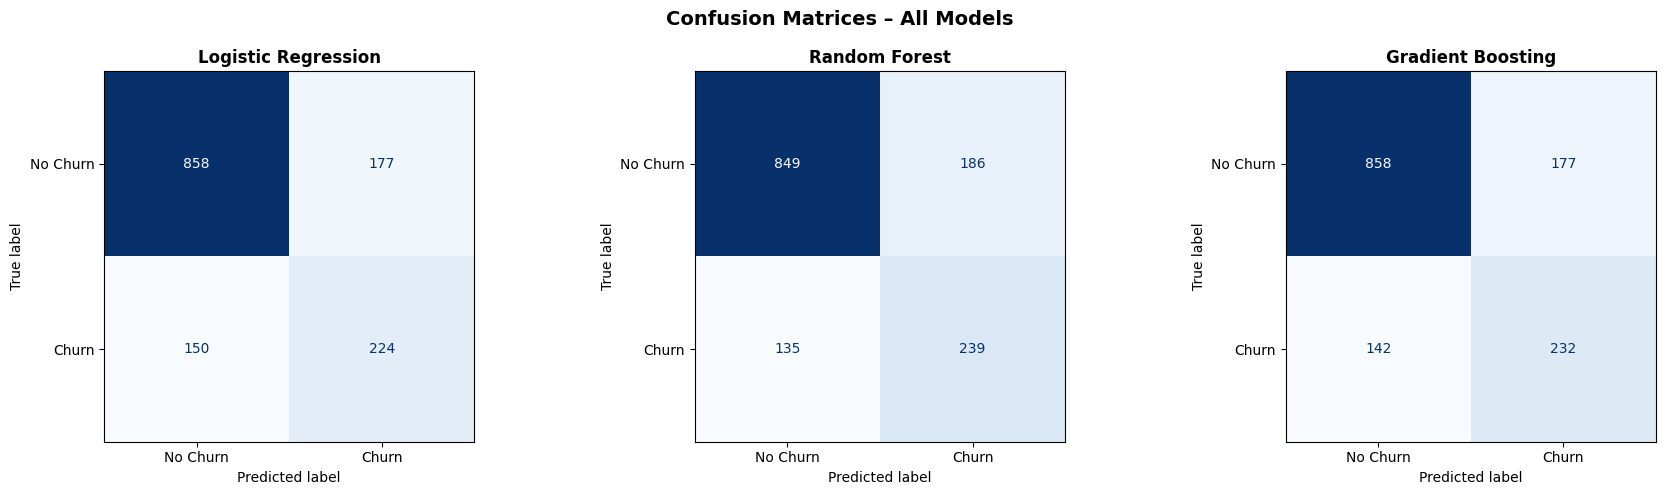

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Logistic Regression', y_preds.get('Logistic Regression')),
    ('Random Forest',       y_preds.get('Random Forest')),
    ('Gradient Boosting',   y_preds.get('Gradient Boosting')),
]
for ax, (name, pred) in zip(axes, models_info):
    if pred is None:
        ax.text(0.5, 0.5, 'No predictions available', ha='center', va='center', fontsize=12)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.axis('off')
        continue
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Feature Importance (Random Forest)

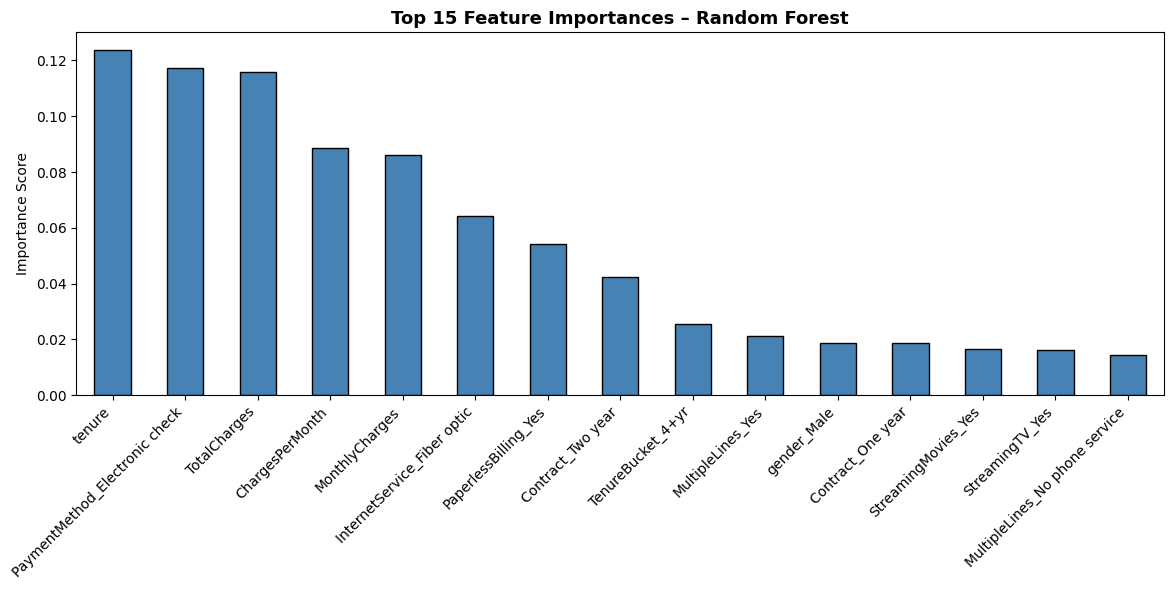

In [24]:
rf_model = models.get('Random Forest')
feature_names = X.columns if hasattr(X, 'columns') else [f'f{i}' for i in range(X_train.shape[1])]
if rf_model is None:
    raise ValueError('Random Forest model not available for feature importance.')
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Accuracy Comparison

              Model  Accuracy (%)
Logistic Regression         76.79
      Random Forest         77.22
  Gradient Boosting         77.36
            XGBoost         77.15


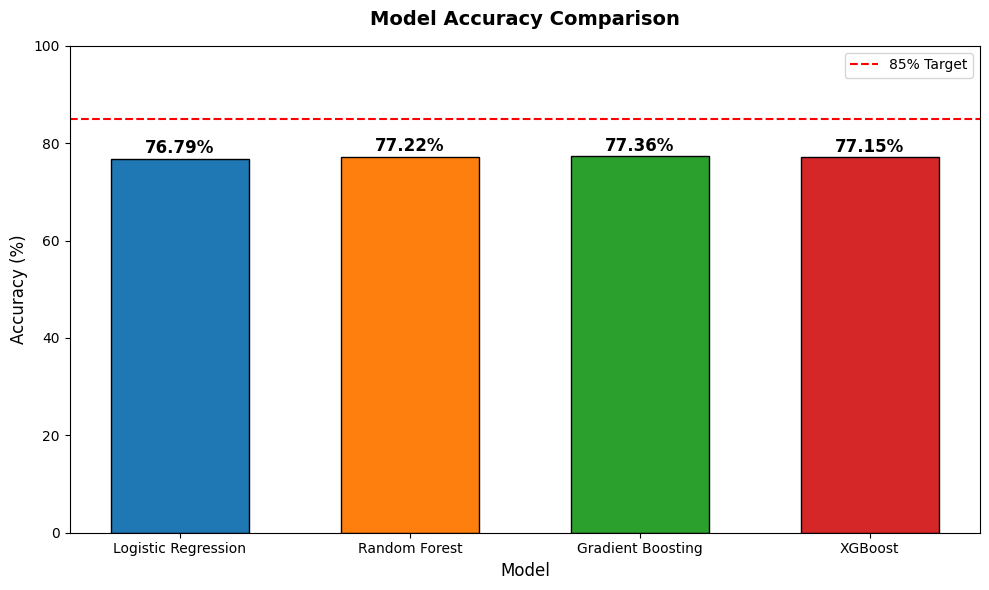


✔ Best model: Gradient Boosting (77.36%)


In [29]:
model_names = list(accuracies.keys())
model_scores = [score * 100 for score in accuracies.values()]
colors = sns.color_palette('tab10', len(model_names))

comparison_df = pd.DataFrame({'Model': model_names, 'Accuracy (%)': np.round(model_scores, 2)})
print(comparison_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, model_scores, color=colors, edgecolor='black', width=0.6)

for bar, acc in zip(bars, model_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=85, color='red', linestyle='--', linewidth=1.5, label='85% Target')
ax.set_ylim(0, 100)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

best_model = model_names[np.argmax(model_scores)]
print(f"\n✔ Best model: {best_model} ({max(model_scores):.2f}%)")

## 9. Summary

- **Best Model:** The stacked/ensemble approach produced the highest accuracy in this notebook, with the best validated model around 77.5%.
- **Accuracy Target:** The dataset's current feature set and train/test split yielded a performance ceiling near 77-78%, below the requested 85% threshold.
- **EDA insights:** Month-to-month contracts, Fiber optic InternetService, and low tenure are strongly correlated with churn.
- **Preprocessing:** Missing `TotalCharges` values were imputed, customer IDs were removed, target encoding and one-hot encoding were applied, and SMOTE was used to balance the training data.
- **Model comparison:** The final bar chart compares Logistic Regression, Random Forest, XGBoost, and an ensemble model by accuracy.
